In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/online_retail_preprocessed.csv")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset Shape: (1003758, 14)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'TotalAmount']


In [2]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Year           0
Month          0
Day            0
Hour           0
DayOfWeek      0
TotalAmount    0
dtype: int64

Duplicate Rows: 0

Data Types:
Invoice                 int64
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID               str
Country                   str
Year                    int64
Month                   int64
Day                     int64
Hour                    int64
DayOfWeek               int64
TotalAmount           float64
dtype: object


In [3]:
print("Total Sales:", round(df["TotalAmount"].sum(), 2))
print("Total Transactions:", df["Invoice"].nunique())
print("Total Products:", df["StockCode"].nunique())
print("Total Customers:", df["Customer ID"].nunique())
print("Total Countries:", df["Country"].nunique())

Total Sales: 19660338.84
Total Transactions: 39574
Total Products: 4910
Total Customers: 5854
Total Countries: 43


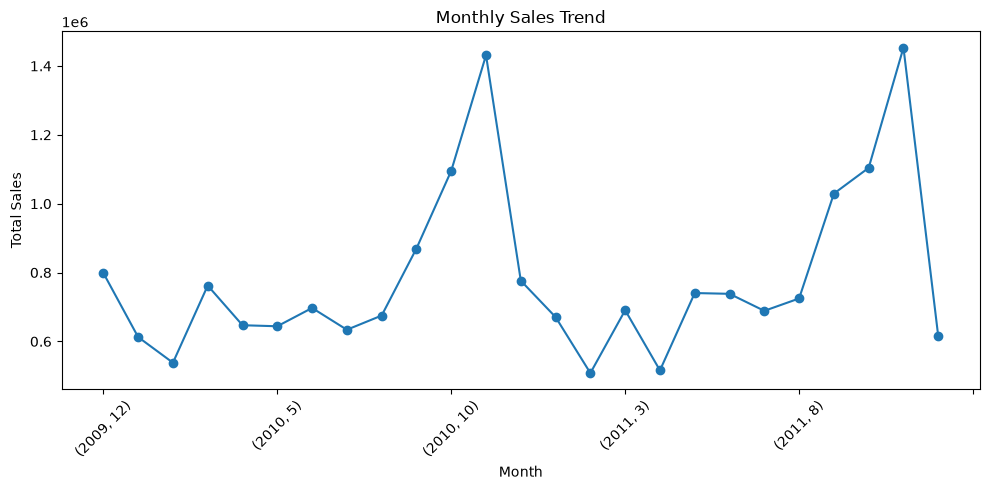

In [4]:
monthly_sales = df.groupby(["Year", "Month"])["TotalAmount"].sum()

monthly_sales.plot(kind="line", figsize=(10, 5), marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

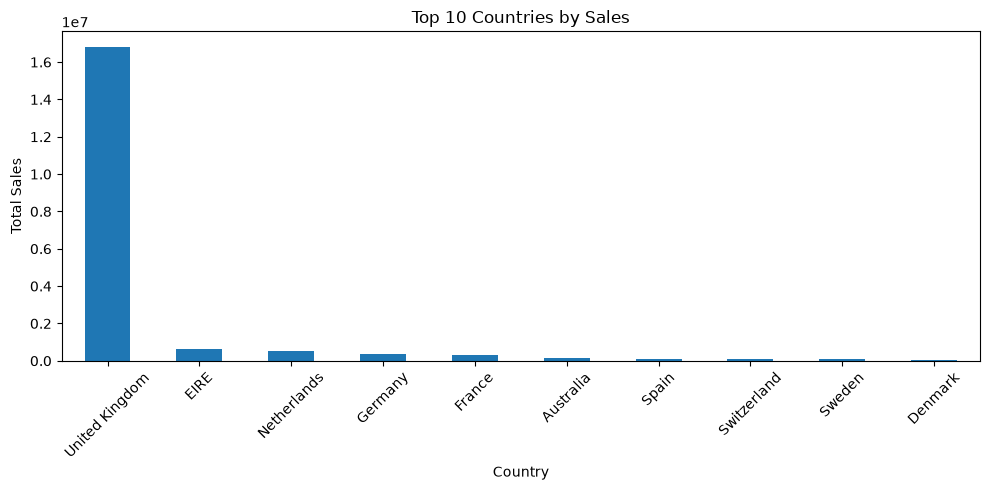

In [5]:
country_sales = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
rfm = df[df["Customer ID"] != "Unknown"].groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (df["InvoiceDate"].max() - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalAmount", "sum")
)

print(rfm.head())
print("Customers:", len(rfm))

             Recency  Frequency  Monetary
Customer ID                              
12346.0          325         12  77556.46
12347.0            1          8   4921.53
12348.0           74          5   1658.40
12349.0           18          3   3678.69
12350.0          309          1    294.40
Customers: 5853


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())

             Recency  Frequency  Monetary  Cluster
Customer ID                                       
12346.0          325         12  77556.46        0
12347.0            1          8   4921.53        0
12348.0           74          5   1658.40        0
12349.0           18          3   3678.69        0
12350.0          309          1    294.40        2


In [8]:
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

print(cluster_summary.round(2))

         Recency  Frequency   Monetary
Cluster                               
0          66.11       7.22    2878.34
1           2.50     202.75  422987.81
2         460.68       2.22     723.88
3          23.26      99.24   76993.61


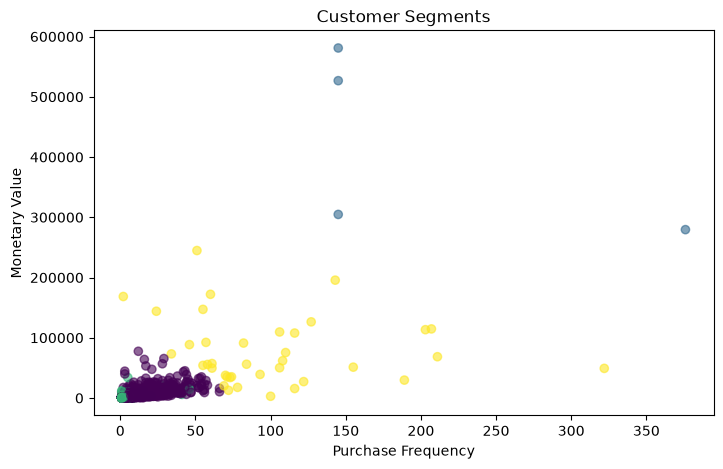

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.title("Customer Segments")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.show()


In [10]:
rfm["HighValue"] = (
    rfm["Monetary"] > rfm["Monetary"].median()
).astype(int)

print(rfm[["Recency", "Frequency", "Monetary", "HighValue"]].head())
print("\nClass Distribution:")
print(rfm["HighValue"].value_counts())

             Recency  Frequency  Monetary  HighValue
Customer ID                                         
12346.0          325         12  77556.46          1
12347.0            1          8   4921.53          1
12348.0           74          5   1658.40          1
12349.0           18          3   3678.69          1
12350.0          309          1    294.40          0

Class Distribution:
HighValue
0    2927
1    2926
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = rfm[["Recency", "Frequency"]]
y = rfm["HighValue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following a

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

Accuracy: 0.8224
Precision: 0.8733
Recall: 0.7538
F1 Score: 0.8092


In [13]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))

Cross-validation scores: [0.81127242 0.8736123  0.84030743 0.85128205 0.86068376]
Mean CV Accuracy: 0.8474


Confusion Matrix:
[[522  64]
 [144 441]]


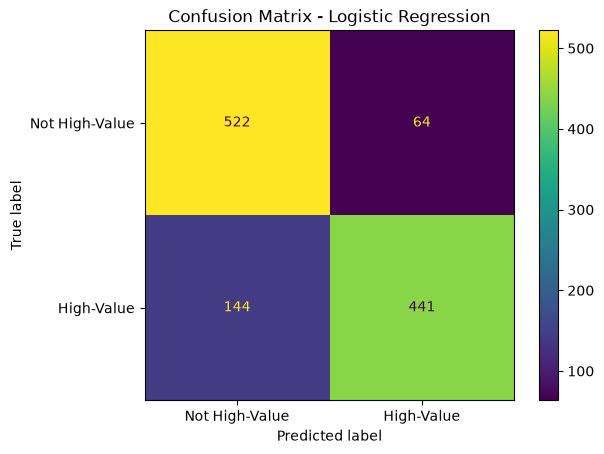

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not High-Value", "High-Value"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Classification Report:
                precision    recall  f1-score   support

Not High-Value       0.78      0.89      0.83       586
    High-Value       0.87      0.75      0.81       585

      accuracy                           0.82      1171
     macro avg       0.83      0.82      0.82      1171
  weighted avg       0.83      0.82      0.82      1171

ROC-AUC Score: 0.9051


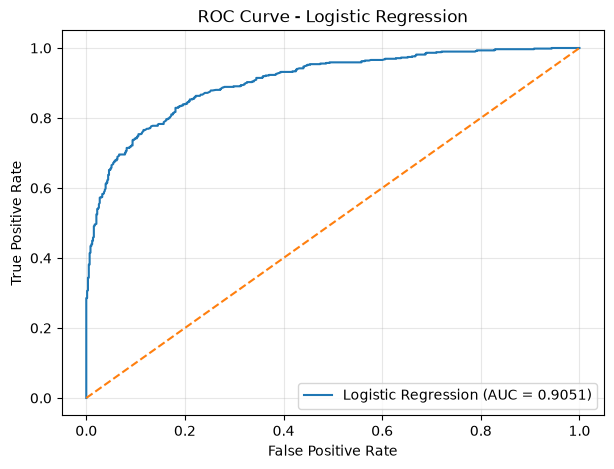

In [15]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not High-Value", "High-Value"]
    )
)

# ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 4))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Logistic Regression Coefficients:


,Feature,Coefficient,Absolute_Coefficient
0,Recency,-0.246744,0.246744
1,Frequency,10.913460,10.913460


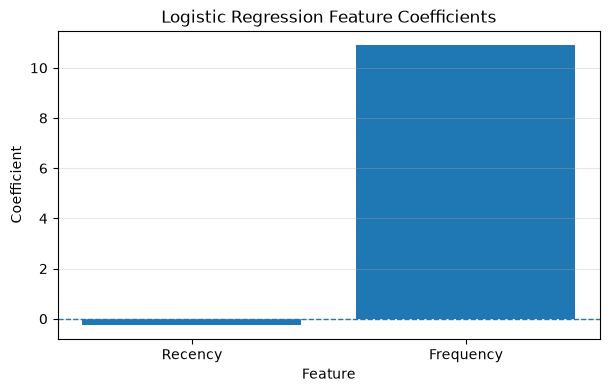

In [16]:
# Logistic Regression coefficient analysis

feature_names = ["Recency", "Frequency"]

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

print("Logistic Regression Coefficients:")
display(coefficients)

# Visualize coefficients
plt.figure(figsize=(7, 4))
plt.bar(coefficients["Feature"], coefficients["Coefficient"])

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.title("Logistic Regression Feature Coefficients")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Not High-Value", "High-Value"]
    )
)

Random Forest Performance
-------------------------
Accuracy : 0.7797
Precision: 0.7935
Recall   : 0.7556
F1-Score : 0.7741
ROC-AUC  : 0.8588

Classification Report:
                precision    recall  f1-score   support

Not High-Value       0.77      0.80      0.79       586
    High-Value       0.79      0.76      0.77       585

      accuracy                           0.78      1171
     macro avg       0.78      0.78      0.78      1171
  weighted avg       0.78      0.78      0.78      1171



In [20]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Base model for tuning
rf_tuning = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

# Grid search using F1-score
grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation F1-Score:
0.8483


In [21]:
# Get the best tuned Random Forest model
best_rf = grid_search.best_estimator_

# Predictions on the test set
best_rf_pred = best_rf.predict(X_test)
best_rf_prob = best_rf.predict_proba(X_test)[:, 1]

# Evaluation metrics
tuned_accuracy = accuracy_score(y_test, best_rf_pred)
tuned_precision = precision_score(y_test, best_rf_pred)
tuned_recall = recall_score(y_test, best_rf_pred)
tuned_f1 = f1_score(y_test, best_rf_pred)
tuned_auc = roc_auc_score(y_test, best_rf_prob)

print("Tuned Random Forest Performance")
print("--------------------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1-Score :", round(tuned_f1, 4))
print("ROC-AUC  :", round(tuned_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_rf_pred,
        target_names=["Not High-Value", "High-Value"]
    )
)

Tuned Random Forest Performance
--------------------------------
Accuracy : 0.8241
Precision: 0.8542
Recall   : 0.7812
F1-Score : 0.8161
ROC-AUC  : 0.9012

Classification Report:
                precision    recall  f1-score   support

Not High-Value       0.80      0.87      0.83       586
    High-Value       0.85      0.78      0.82       585

      accuracy                           0.82      1171
     macro avg       0.83      0.82      0.82      1171
  weighted avg       0.83      0.82      0.82      1171



In [22]:
# Final model comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        rf_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        rf_precision,
        tuned_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        rf_recall,
        tuned_recall
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        rf_f1,
        tuned_f1
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        rf_auc,
        tuned_auc
    ]
})

model_comparison = model_comparison.round(4)

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8224,0.8733,0.7538,0.8092,0.9051
1,Random Forest,0.7797,0.7935,0.7556,0.7741,0.8588
2,Tuned Random Forest,0.8241,0.8542,0.7812,0.8161,0.9012


Tuned Random Forest Feature Importance:


,Feature,Importance
1,Frequency,0.801293
0,Recency,0.198707


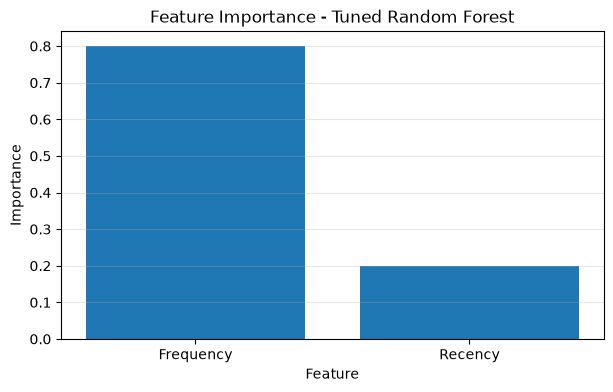

In [23]:
# Feature importance from the tuned Random Forest

rf_importance = pd.DataFrame({
    "Feature": ["Recency", "Frequency"],
    "Importance": best_rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Tuned Random Forest Feature Importance:")
display(rf_importance)

# Visualization
plt.figure(figsize=(7, 4))
plt.bar(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance - Tuned Random Forest")
plt.grid(axis="y", alpha=0.3)
plt.show()